# 6D-VHQ Analysis Notebook 6: Analysis of Experiment 3 (online psychedelics study) 

## File Setup

In [1]:

## libraries

import pandas as pd
from pathlib import Path
import os
from collections import defaultdict
import ast
import re
import statsmodels.api as sm
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import numpy as np

In [2]:
### filepaths ###

project_path =  Path().resolve().parent 
data_path = os.path.join(project_path, "raw_data")
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")
imgs_path = os.path.join(project_path, "imgs")


## Recall Study Data Import

In [3]:
### import data tables

df_vhq_rec_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_rec_dims.csv"))
display(df_vhq_rec_dims)

df_background_rec = pd.read_csv(os.path.join(tables_path, "df_background_rec.csv")) 
display(df_background_rec)

df_asc_rec_dims = pd.read_csv(os.path.join(tables_path, "df_asc_rec_dims.csv"))
display(df_asc_rec_dims)

,ResponseId,geometric,semantic,detail,vividness,entropy,focality
0,R_2XhSm3rVuTDh2XT,1.333333,5.000000,5.000000,4.333333,1.666667,2.666667
1,R_82J66rTAKMAkEMO,1.666667,2.000000,3.333333,5.000000,1.666667,1.333333
2,R_80OjC1M5y1RxlPM,5.000000,4.333333,2.000000,4.333333,1.666667,3.000000
3,R_8rdBxiZHeShoPvf,5.000000,1.333333,3.333333,3.333333,3.000000,4.000000
4,R_2rH7YSrGIo4VOqn,5.000000,3.666667,5.000000,5.000000,2.333333,3.000000
...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,5.000000,2.333333,5.000000,5.000000,1.000000,1.000000
197,R_1levP6TzI6EFeP7,3.666667,3.666667,4.000000,4.333333,4.333333,1.333333
198,R_6QEuAAP3YqW0Th7,3.666667,2.666667,4.333333,4.000000,1.000000,2.666667
199,R_6rF4jrVpI9mVj9v,3.000000,3.000000,5.000000,5.000000,1.000000,3.666667


,ResponseId,substance_codes,substance_labels,primary_substance_code,primary_substance,dosage_code,dosage_label,dosage_text,other_substances_any,other_substances_text,stage_code,stage_label,when_code,when_label
0,R_2XhSm3rVuTDh2XT,[2],Psilocybin,2.0,Psilocybin,5.0,very high,7g,False,NaN,4,late middle,2,within the past month
1,R_82J66rTAKMAkEMO,[2],Psilocybin,2.0,Psilocybin,NaN,Not reported,2.5gms psychedelic mushrooms,False,NaN,2,early middle,1,within the past week
2,R_80OjC1M5y1RxlPM,[3],Ayahuasca,3.0,Ayahuasca,4.0,high,NaN,False,NaN,3,middle,3,within the past 3 months
3,R_8rdBxiZHeShoPvf,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,1 and a half grams of magic mushrooms,True,NaN,5,end,4,within the past 6 months
4,R_2rH7YSrGIo4VOqn,[2],Psilocybin,2.0,Psilocybin,2.0,small,0.5 grams,False,NaN,1,beginning,1,within the past week
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,[6],5-MeO-DMT,6.0,5-MeO-DMT,3.0,moderate,Roughly .02mg,False,NaN,3,middle,1,within the past week
197,R_1levP6TzI6EFeP7,[1],LSD,1.0,LSD,4.0,high,200,True,NaN,3,middle,1,within the past week
198,R_6QEuAAP3YqW0Th7,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,4 grams,False,NaN,1,beginning,1,within the past week
199,R_6rF4jrVpI9mVj9v,[2],Psilocybin,2.0,Psilocybin,3.0,moderate,4 grams,False,NaN,1,beginning,1,within the past week


,ResponseId,experience_of_unity,spiritual_experience,blissful_state,insightfulness,disembodiment,impaired_control_and_cognition,anxiety,complex_imagery,elementary_imagery,audio_visual_synesthesia,changed_meaning_of_percepts
0,R_2XhSm3rVuTDh2XT,56.6,30.666667,80.666667,51.000000,2.333333,6.125,22.2,68.333333,2.333333,13.666667,32.333333
1,R_82J66rTAKMAkEMO,19.8,22.666667,19.666667,41.666667,11.000000,11.000,23.2,42.333333,14.666667,22.000000,21.000000
2,R_80OjC1M5y1RxlPM,90.8,72.666667,81.000000,88.333333,100.000000,28.875,33.4,59.333333,63.666667,85.000000,95.333333
3,R_8rdBxiZHeShoPvf,10.2,4.000000,43.666667,36.666667,36.000000,3.875,5.4,47.666667,28.000000,5.666667,10.333333
4,R_2rH7YSrGIo4VOqn,25.2,46.666667,77.000000,39.000000,8.666667,17.750,16.4,55.666667,69.666667,100.000000,23.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
196,R_7cTzDfiLPQ0wBC9,98.0,66.000000,99.000000,65.333333,99.333333,6.375,20.8,24.333333,33.000000,15.000000,45.333333
197,R_1levP6TzI6EFeP7,30.6,33.333333,47.666667,38.000000,21.333333,18.875,18.8,66.666667,66.666667,100.000000,8.333333
198,R_6QEuAAP3YqW0Th7,28.4,29.666667,44.333333,20.000000,16.000000,16.750,28.8,34.666667,33.000000,78.333333,23.000000
199,R_6rF4jrVpI9mVj9v,25.6,48.000000,44.333333,27.000000,7.000000,7.375,17.4,34.333333,30.333333,90.666667,9.666667


In [4]:
### create lists of dimension names

vhq_dimension_columns = df_vhq_rec_dims.columns.tolist()
asc_dimension_columns = df_asc_rec_dims.columns.tolist()

vhq_dimension_columns.remove("ResponseId")
asc_dimension_columns.remove("ResponseId")

print("VHQ dimension columns:", vhq_dimension_columns)
print("ASC dimension columns:", asc_dimension_columns)

# --- VHQ: rename first two items ---
vhq_dimensions = vhq_dimension_columns.copy()
vhq_dimensions[0] = "geometric content"
vhq_dimensions[1] = "semantic content"

# --- ASC: replace underscores with spaces ---
asc_dimensions = [c.replace("_", " ") for c in asc_dimension_columns]


print("VHQ dimensions:", vhq_dimensions)
print("ASC dimensions:", asc_dimensions)

VHQ dimension columns: ['geometric', 'semantic', 'detail', 'vividness', 'entropy', 'focality']
ASC dimension columns: ['experience_of_unity', 'spiritual_experience', 'blissful_state', 'insightfulness', 'disembodiment', 'impaired_control_and_cognition', 'anxiety', 'complex_imagery', 'elementary_imagery', 'audio_visual_synesthesia', 'changed_meaning_of_percepts']
VHQ dimensions: ['geometric content', 'semantic content', 'detail', 'vividness', 'entropy', 'focality']
ASC dimensions: ['experience of unity', 'spiritual experience', 'blissful state', 'insightfulness', 'disembodiment', 'impaired control and cognition', 'anxiety', 'complex imagery', 'elementary imagery', 'audio visual synesthesia', 'changed meaning of percepts']


## Sample Sizes by Substance

In [5]:
SUBSTANCE_MAP = {
    1: "LSD", 2: "Psilocybin", 3: "Ayahuasca", 4: "DMT",
    6: "5-MeO-DMT", 5: "Mescaline", 7: "2C-B", 8: "Salvia",
    9: "Iboga", 11: "Other"
}

In [6]:

# --- 1. Parse `substance_codes` column from text to Python lists of ints ---

def parse_code_list(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    # Handle strings like "[2, 3]" safely
    try:
        parsed = ast.literal_eval(str(x))
    except (SyntaxError, ValueError):
        # Fallback: try to split on commas
        parsed = [int(p.strip()) for p in str(x).split(",") if p.strip().isdigit()]
    # Ensure list of ints
    return [int(c) for c in parsed]

df_background_rec["substance_codes_list"] = df_background_rec["substance_codes"].apply(parse_code_list)

# --- 2. Map codes to human-readable labels, including specific "Other" substances ---

def get_substance_labels(row):
    labels = []
    codes = row["substance_codes_list"]
    other_text = row.get("other_substances_text", None)

    for code in codes:
        if code == 11:
            # Use typed "other" text if available, otherwise fall back to generic "Other"
            if isinstance(other_text, str) and other_text.strip():
                # Normalise spacing and case a bit (so "dxm" and "DXM " are treated the same)
                label = other_text.strip()
                # Optional: standardise to upper-case to combine variants like "dxm", "Dxm", etc.
                label = label.upper()
            else:
                label = SUBSTANCE_MAP.get(code, f"Code_{code}")
        else:
            label = SUBSTANCE_MAP.get(code, f"Code_{code}")
        labels.append(label)

    # Remove duplicates within a trip, just in case
    return list(dict.fromkeys(labels))

df_background_rec["substance_labels"] = df_background_rec.apply(get_substance_labels, axis=1)

# --- 3. Build mappings: substance -> set of ResponseIds, and ResponseId -> set of substances ---

substance_to_responses = defaultdict(set)
response_to_substances = defaultdict(set)

for _, row in df_background_rec.iterrows():
    rid = row["ResponseId"]
    subs = row["substance_labels"]

    for s in subs:
        substance_to_responses[s].add(rid)
        response_to_substances[rid].add(s)

# --- 4. Compute total and exclusive counts, sort from most to least reported ---

summary = []
for substance, response_ids in substance_to_responses.items():
    total_n = len(response_ids)
    # Exclusive = trips where this is the only substance reported
    exclusive_n = sum(
        1
        for rid in response_ids
        if len(response_to_substances[rid]) == 1
    )
    summary.append((substance, total_n, exclusive_n))

# Sort by total_n descending, then by name
summary.sort(key=lambda x: (-x[1], x[0]))

# --- 5. Print verbose summary ---

print("Substance-wise sample sizes (including multi-substance trips):\n")
for substance, total_n, exclusive_n in summary:
    print(
        f"{substance}: "
        f"{total_n} trips reported using this substance "
        f"(of which {exclusive_n} trips used {substance} exclusively, "
        f"with no other substances reported)."
    )


Substance-wise sample sizes (including multi-substance trips):

Psilocybin: 101 trips reported using this substance (of which 93 trips used Psilocybin exclusively, with no other substances reported).
LSD: 34 trips reported using this substance (of which 25 trips used LSD exclusively, with no other substances reported).
DMT: 25 trips reported using this substance (of which 15 trips used DMT exclusively, with no other substances reported).
Other: 17 trips reported using this substance (of which 15 trips used Other exclusively, with no other substances reported).
Ayahuasca: 14 trips reported using this substance (of which 11 trips used Ayahuasca exclusively, with no other substances reported).
5-MeO-DMT: 12 trips reported using this substance (of which 8 trips used 5-MeO-DMT exclusively, with no other substances reported).
2C-B: 5 trips reported using this substance (of which 2 trips used 2C-B exclusively, with no other substances reported).
Mescaline: 5 trips reported using this substanc

## Table 1

In [7]:

# ============================================================
# Substance summary table with requested changes
#   - "OTHER:" prefix removed; "other" is catch-all bin
#   - Any label with <5 reports is binned into "other"
#   - Rows ordered by Any use N desc
#   - Columns: Substance | Any use (N, %) | Exclusive use (N)
#   - Display in a copy/paste-friendly format
# ============================================================

# ----------------------------
# 1) Parse `substance_codes` column
# ----------------------------

def parse_code_list(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    try:
        parsed = ast.literal_eval(str(x))
    except (SyntaxError, ValueError):
        parsed = [int(p.strip()) for p in str(x).split(",") if p.strip().isdigit()]
    return [int(c) for c in parsed]

df = df_background_rec.copy()
df["substance_codes_list"] = df["substance_codes"].apply(parse_code_list)

# ----------------------------
# 2) Clean + split free-text "Other"
# ----------------------------

_SPLIT_RE = re.compile(r"[;/\|]|,|\+|&|\band\b", flags=re.IGNORECASE)

def normalize_other_token(t: str) -> str:
    t = t.strip()
    if not t:
        return ""
    t = re.sub(r"\s+", " ", t)
    t = t.upper()
    return t

def split_other_text(other_text):
    if not isinstance(other_text, str) or not other_text.strip():
        return []
    raw = other_text.strip()
    parts = [p for p in _SPLIT_RE.split(raw) if p and p.strip()]
    toks = [normalize_other_token(p) for p in parts]
    toks = [t for t in toks if t]

    # de-duplicate within-row while preserving order
    seen = set()
    out = []
    for t in toks:
        if t not in seen:
            out.append(t)
            seen.add(t)
    return out

# ----------------------------
# 3) Map codes -> labels
#    - Code 11: free-text tokens, or "other" if missing
#    - No "OTHER:" prefix: tokens appear directly (e.g., "DXM")
# ----------------------------

OTHER_CODE = 11

def get_substance_labels(row):
    labels = []
    codes = row["substance_codes_list"]
    other_tokens = split_other_text(row.get("other_substances_text", None))

    for code in codes:
        if code == OTHER_CODE:
            if other_tokens:
                labels.extend(other_tokens)  # tokens only
            else:
                labels.append("other")
        else:
            labels.append(SUBSTANCE_MAP.get(code, f"CODE_{code}"))

    # de-duplicate within-row
    return list(dict.fromkeys(labels))

df["substance_labels"] = df.apply(get_substance_labels, axis=1)

# ----------------------------
# 4) Build response↔substance mappings (pre-binning)
# ----------------------------

substance_to_responses = defaultdict(set)
response_to_substances = defaultdict(set)

for _, row in df.iterrows():
    rid = row["ResponseId"]
    subs = row["substance_labels"]
    for s in subs:
        substance_to_responses[s].add(rid)
        response_to_substances[rid].add(s)

N_total = df["ResponseId"].nunique()

# ----------------------------
# 5) Bin rare substances (<5 any-use) into "other"
#    - Also collapses everything already labeled "other"
# ----------------------------

MIN_ANY_USE_FOR_OWN_ROW = 5

# Identify labels to bin
to_bin = set()
for s, rids in substance_to_responses.items():
    if s == "other":
        continue
    if len(rids) < MIN_ANY_USE_FOR_OWN_ROW:
        to_bin.add(s)

# Build binned response_to_substances_binned
response_to_substances_binned = {}
for rid, subs in response_to_substances.items():
    new_subs = set()
    for s in subs:
        if s == "other" or s in to_bin:
            new_subs.add("other")
        else:
            new_subs.add(s)
    response_to_substances_binned[rid] = new_subs

# Build binned substance_to_responses_binned
substance_to_responses_binned = defaultdict(set)
for rid, subs in response_to_substances_binned.items():
    for s in subs:
        substance_to_responses_binned[s].add(rid)

# ----------------------------
# 6) Create summary table (Any use N,% ; Exclusive N)
# ----------------------------

rows = []
for substance, rids in substance_to_responses_binned.items():
    any_n = len(rids)
    exclusive_n = sum(1 for rid in rids if len(response_to_substances_binned[rid]) == 1)
    rows.append({
        "Substance": substance,
        "Any_N": any_n,
        "Any_%": 100.0 * any_n / N_total if N_total else 0.0,
        "Exclusive_N": exclusive_n,
    })

summary_df = pd.DataFrame(rows).sort_values(
    by=["Any_N", "Substance"], ascending=[False, True]
).reset_index(drop=True)

paper_table = summary_df.copy()
paper_table["Any use"] = paper_table.apply(lambda r: f'{int(r["Any_N"])} ({r["Any_%"]:.1f}%)', axis=1)
paper_table["Exclusive use"] = paper_table["Exclusive_N"].astype(int)

paper_table = paper_table[["Substance", "Any use", "Exclusive use"]]

# ----------------------------
# 7) Display (copy/paste-friendly)
# ----------------------------


display(paper_table)

# Also print as TSV for easy copy/paste into Sheets if needed
print("\nCopy/paste (TSV):\n")
print(paper_table.to_csv(sep="\t", index=False))

print(f"\nTotal unique trips (N): {N_total}")



,Substance,Any use,Exclusive use
0,Psilocybin,101 (50.2%),93
1,LSD,34 (16.9%),25
2,other,32 (15.9%),24
3,DMT,25 (12.4%),15
4,Ayahuasca,14 (7.0%),11
5,5-MeO-DMT,12 (6.0%),8
6,2C-B,5 (2.5%),2
7,Mescaline,5 (2.5%),4



Copy/paste (TSV):

Substance	Any use	Exclusive use
Psilocybin	101 (50.2%)	93
LSD	34 (16.9%)	25
other	32 (15.9%)	24
DMT	25 (12.4%)	15
Ayahuasca	14 (7.0%)	11
5-MeO-DMT	12 (6.0%)	8
2C-B	5 (2.5%)	2
Mescaline	5 (2.5%)	4


Total unique trips (N): 201


## sample size by dosage

In [8]:
# ============================================================
# Dosage summary table
#   - dosage_code meanings:
#       1 = very small
#       2 = small
#       3 = moderate
#       4 = high
#       5 = very high
#       anything else / missing = unknown
#   - Columns: Reported dosage | N
#   - Ordered: very small -> very high -> unknown
#   - Display only
# ============================================================

# ----------------------------
# 0) Choose input dataframe
# ----------------------------
if "df_background_rec" in globals():
    df = df_background_rec.copy()
elif "df" in globals():
    df = df.copy()
else:
    raise NameError("Neither `df_background_rec` nor `df` exists. Define your input dataframe first.")

# ----------------------------
# 1) Map dosage codes to labels
# ----------------------------
DOSAGE_MAP = {
    1: "very small",
    2: "small",
    3: "moderate",
    4: "high",
    5: "very high",
}

def map_dosage(x):
    try:
        x = int(x)
    except Exception:
        return "unknown"
    return DOSAGE_MAP.get(x, "unknown")

df["reported_dosage"] = df["dosage_code"].apply(map_dosage)

# ----------------------------
# 2) Count N per dosage category
# ----------------------------
dosage_counts = (
    df["reported_dosage"]
    .value_counts(dropna=False)
    .rename_axis("Reported dosage")
    .reset_index(name="N")
)

# ----------------------------
# 3) Enforce ordering
# ----------------------------
ORDER = ["very small", "small", "moderate", "high", "very high", "unknown"]

dosage_counts["Reported dosage"] = pd.Categorical(
    dosage_counts["Reported dosage"],
    categories=ORDER,
    ordered=True,
)

dosage_table = dosage_counts.sort_values("Reported dosage").reset_index(drop=True)

display(dosage_table)

print(f"\nTotal rows counted: {dosage_table['N'].sum()}")


,Reported dosage,N
0,very small,2
1,small,15
2,moderate,83
3,high,78
4,very high,19
5,unknown,4



Total rows counted: 201


## substance analysis

In [11]:
# ---- Substance → dimensional profile analysis with ONE omnibus test per dimension (+ dosage covariate) ----
# Adds:
#   - dosage_code (1–5) as linear covariate
#   - imputes invalid/missing dosage to 3
#   - prints how many values were imputed
#
# Produces:
#   (1) MANOVA global multivariate test (per questionnaire)
#   (2) One omnibus (block) F-test per dimension: H0: all substance betas (incl. Other) = 0
# Optional: coefficient matrix for descriptive patterning


MIN_N = 10
NUISANCE_SUBSTANCE = "Other"
DOSAGE_COL = "dosage_code"
DOSAGE_IMPUTE_VALUE = 3


# ------------------------
# Helpers
# ------------------------

def _coerce_substance_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return [int(v) for v in x if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if isinstance(x, (tuple, set)):
        return [int(v) for v in list(x)]
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return [int(v) for v in val if v is not None]
            if isinstance(val, (tuple, set)):
                return [int(v) for v in list(val)]
            if isinstance(val, (int, float)):
                return [int(val)]
        except Exception:
            parts = [p.strip() for p in s.replace("[", "").replace("]", "").split(",") if p.strip() != ""]
            out = []
            for p in parts:
                try:
                    out.append(int(p))
                except Exception:
                    pass
            return out
    if isinstance(x, (int, np.integer)):
        return [int(x)]
    if isinstance(x, (float, np.floating)) and not np.isnan(x):
        return [int(x)]
    return []


def build_substance_indicators(df_background, response_id_col="ResponseId", codes_col="substance_codes"):
    df = df_background.copy()
    df[codes_col] = df[codes_col].apply(_coerce_substance_list)

    for code, name in SUBSTANCE_MAP.items():
        col = f"sub_{name}"
        df[col] = df[codes_col].apply(lambda lst: int(code in set(lst)))

    counts = {f"sub_{name}": int(df[f"sub_{name}"].sum()) for name in SUBSTANCE_MAP.values()}
    return df, counts


def select_predictors(counts, min_n=MIN_N, nuisance=NUISANCE_SUBSTANCE):
    preds = []
    nuisance_col = f"sub_{nuisance}"

    for col, n in counts.items():
        name = col.replace("sub_", "")
        if name == nuisance:
            preds.append(col)
        elif n >= min_n:
            preds.append(col)

    if nuisance_col in counts and nuisance_col not in preds:
        preds.append(nuisance_col)

    preds_sorted = [p for p in preds if p != nuisance_col] + ([nuisance_col] if nuisance_col in preds else [])
    return preds_sorted


def _ensure_numeric(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def _make_safe_names(cols):
    rename = {}
    used = set()
    for c in cols:
        s = str(c)
        s2 = re.sub(r"[^0-9A-Za-z_]", "_", s)
        if re.match(r"^[0-9]", s2):
            s2 = "c_" + s2
        if s2 == "":
            s2 = "c"
        base = s2
        k = 1
        while s2 in used:
            k += 1
            s2 = f"{base}_{k}"
        used.add(s2)
        rename[c] = s2
    inv = {v: k for k, v in rename.items()}
    return rename, inv


def add_dosage_linear_with_imputation(df_bg, dosage_col=DOSAGE_COL, impute_value=DOSAGE_IMPUTE_VALUE):
    """
    Creates a clean numeric dosage column in [1..5], imputing invalid/missing to impute_value.
    Returns (df_bg_out, n_imputed, n_invalid_raw, n_missing_raw).
    """
    out = df_bg.copy()

    # Coerce to numeric (invalid strings -> NaN)
    raw = pd.to_numeric(out.get(dosage_col, np.nan), errors="coerce")

    # Mark valid in 1..5
    valid = raw.isin([1, 2, 3, 4, 5])

    # Count missing/invalid for reporting
    n_missing_raw = int(raw.isna().sum())
    n_invalid_raw = int((~raw.isna() & ~valid).sum())
    n_imputed = int((~valid).sum())  # includes NaN and out-of-range

    # Impute
    cleaned = raw.where(valid, other=impute_value).astype(float)

    out["dosage_linear"] = cleaned
    return out, n_imputed, n_invalid_raw, n_missing_raw


# ------------------------
# Main analysis function
# ------------------------

def run_multivariate_profile_omnibus(
    df_dims,
    df_background,
    questionnaire_name,
    response_id_col="ResponseId",
    codes_col="substance_codes",
    min_n=10,
    nuisance="Other",
    drop_allzero_substance_rows=False,
    robust_cov="HC3",
    correct_omnibus_p_holm=True,
    make_coef_matrix=True,
    dosage_col=DOSAGE_COL,
    dosage_impute_value=DOSAGE_IMPUTE_VALUE,
):
    # Build indicator columns and dosage covariate
    df_bg_ind, counts = build_substance_indicators(df_background, response_id_col, codes_col)
    df_bg_ind, n_imputed, n_invalid_raw, n_missing_raw = add_dosage_linear_with_imputation(
        df_bg_ind, dosage_col=dosage_col, impute_value=dosage_impute_value
    )

    predictor_cols = select_predictors(counts, min_n=min_n, nuisance=nuisance)

    # Add dosage to predictors (always)
    predictor_cols_plus = predictor_cols + ["dosage_linear"]

    # Merge with outcomes
    df = df_dims.merge(
        df_bg_ind[[response_id_col] + predictor_cols_plus],
        on=response_id_col,
        how="inner"
    )

    dimension_cols = [c for c in df_dims.columns if c != response_id_col]
    df = _ensure_numeric(df, dimension_cols)

    before = len(df)
    df = df.dropna(subset=dimension_cols)
    after = len(df)

    if drop_allzero_substance_rows:
        df = df.loc[df[predictor_cols].sum(axis=1) > 0].copy()

    n_final = len(df)

    print(f"\n=== {questionnaire_name}: substance → dimensional profile (omnibus per dimension; + dosage) ===")
    print(f"Merged rows (inner join): {before}")
    print(f"Rows after dropping missing outcomes: {after}")
    print(f"Final N: {n_final}")

    print(f"\nDosage handling ({dosage_col}):")
    print(f"  Raw missing (NaN after coercion): {n_missing_raw}")
    print(f"  Raw invalid (not in 1..5): {n_invalid_raw}")
    print(f"  Total imputed to {dosage_impute_value}: {n_imputed}")

    included_counts = {col: int(df[col].sum()) for col in predictor_cols}
    print("\nSubstance predictors included (min_n = {0}; nuisance = '{1}'):\n".format(min_n, nuisance))
    for col in predictor_cols:
        print(f"  {col}: n_present={included_counts[col]}")
    print("\nAdditional covariate included:")
    print("  dosage_linear (1–5; invalid/missing imputed to {0})".format(dosage_impute_value))

    # ----- (1) MANOVA global multivariate test -----
    cols_for_manova = dimension_cols + predictor_cols_plus
    rename_map, inv_map = _make_safe_names(cols_for_manova)
    df_m = df[[response_id_col] + cols_for_manova].rename(columns=rename_map).copy()

    dims_safe = [rename_map[c] for c in dimension_cols]
    preds_safe = [rename_map[c] for c in predictor_cols_plus]
    manova_formula = f"{' + '.join(dims_safe)} ~ {' + '.join(preds_safe)}"

    manova = MANOVA.from_formula(manova_formula, data=df_m)
    manova_res = manova.mv_test()

    print("\nMANOVA (global multivariate tests):")
    print(manova_res)

    # ----- (2) One omnibus (block) test per dimension: substances jointly (NOT including dosage) -----
    X = sm.add_constant(df[predictor_cols_plus].copy(), has_constant="add")
    param_names = list(X.columns)

    # Test only the substance indicators jointly; exclude intercept and dosage
    tested_terms = [c for c in predictor_cols if c in X.columns]
    R = np.zeros((len(tested_terms), len(param_names)))
    for i, term in enumerate(tested_terms):
        R[i, param_names.index(term)] = 1

    omnibus_rows = []
    coef_matrix = None

    if make_coef_matrix:
        # Descriptive coefficients for all terms except intercept (includes dosage here for transparency)
        coef_terms = [c for c in X.columns if c != "const"]
        coef_matrix = pd.DataFrame(index=coef_terms, columns=dimension_cols, dtype=float)

    for ycol in dimension_cols:
        y = df[ycol].values
        fit = sm.OLS(y, X).fit(cov_type=robust_cov)

        ft = fit.f_test(R)  # H0: all substance coefficients = 0 (conditional on dosage)

        omnibus_rows.append({
            "questionnaire": questionnaire_name,
            "dimension": ycol,
            "N": int(fit.nobs),
            "df_num": int(getattr(ft, "df_num", len(tested_terms))),
            "df_den": int(getattr(ft, "df_denom", fit.df_resid)),
            "F": float(np.asarray(ft.fvalue).squeeze()),
            "p": float(np.asarray(ft.pvalue).squeeze()),
            "R2": float(fit.rsquared),
            "adj_R2": float(fit.rsquared_adj),
        })

        if make_coef_matrix:
            for term in coef_matrix.index:
                coef_matrix.loc[term, ycol] = float(fit.params[term])

    omnibus = pd.DataFrame(omnibus_rows).sort_values("p")

    if correct_omnibus_p_holm:
        rej, p_holm, _, _ = multipletests(omnibus["p"].values, alpha=0.05, method="holm")
        omnibus["p_holm"] = p_holm
        omnibus["rej_holm_0p05"] = rej

    print("\nOmnibus block tests (ONE per dimension): substances jointly (conditional on dosage)")
    display(omnibus)

    return {
        "merged_df": df,
        "dimension_cols": dimension_cols,
        "predictor_cols": predictor_cols,                 # substance predictors only
        "predictor_cols_plus": predictor_cols_plus,       # substances + dosage
        "substance_counts_included": included_counts,
        "n_dosage_imputed": n_imputed,
        "n_dosage_invalid_raw": n_invalid_raw,
        "n_dosage_missing_raw": n_missing_raw,
        "manova_result": manova_res,
        "manova_formula": manova_formula,
        "manova_rename_map": rename_map,
        "omnibus_table": omnibus,
        "coef_matrix": coef_matrix,  # descriptive only
    }

# ------------------------
# Run for VHQ and ASC
# ------------------------

res_vhq = run_multivariate_profile_omnibus(
    df_dims=df_vhq_rec_dims,
    df_background=df_background_rec,
    questionnaire_name="VHQ",
    response_id_col="ResponseId",
    codes_col="substance_codes",
    min_n=10,
    nuisance="Other",
    drop_allzero_substance_rows=False,
    robust_cov="HC3",
    correct_omnibus_p_holm=True,
    make_coef_matrix=True,
    dosage_col="dosage_code",
    dosage_impute_value=3,
)

res_asc = run_multivariate_profile_omnibus(
    df_dims=df_asc_rec_dims,
    df_background=df_background_rec,
    questionnaire_name="ASC",
    response_id_col="ResponseId",
    codes_col="substance_codes",
    min_n=10,
    nuisance="Other",
    drop_allzero_substance_rows=False,
    robust_cov="HC3",
    correct_omnibus_p_holm=True,
    make_coef_matrix=True,
    dosage_col="dosage_code",
    dosage_impute_value=3,
)

# Optional: descriptive coefficient matrices for pattern inspection / heatmaps
print("\nVHQ descriptive coefficient matrix (terms × dimension):")
display(res_vhq["coef_matrix"])

print("\nASC descriptive coefficient matrix (terms × dimension):")
display(res_asc["coef_matrix"])



=== VHQ: substance → dimensional profile (omnibus per dimension; + dosage) ===
Merged rows (inner join): 201
Rows after dropping missing outcomes: 201
Final N: 201

Dosage handling (dosage_code):
  Raw missing (NaN after coercion): 1
  Raw invalid (not in 1..5): 3
  Total imputed to 3: 4

Substance predictors included (min_n = 10; nuisance = 'Other'):

  sub_LSD: n_present=34
  sub_Psilocybin: n_present=101
  sub_Ayahuasca: n_present=14
  sub_DMT: n_present=25
  sub_5-MeO-DMT: n_present=12
  sub_Other: n_present=28

Additional covariate included:
  dosage_linear (1–5; invalid/missing imputed to 3)

MANOVA (global multivariate tests):
                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.3232 6.0000 188.0000 65.6209 0.0000
   

,questionnaire,dimension,N,df_num,df_den,F,p,R2,adj_R2,p_holm,rej_holm_0p05
1,VHQ,semantic,201,6,193,3.413097,0.003179,0.061760,0.027730,0.019076,True
3,VHQ,vividness,201,6,193,2.031116,0.063348,0.027776,-0.007486,0.316738,False
2,VHQ,detail,201,6,193,1.674472,0.129153,0.050405,0.015963,0.516613,False
0,VHQ,geometric,201,6,193,1.532826,0.169295,0.026104,-0.009219,0.516613,False
4,VHQ,entropy,201,6,193,1.513557,0.175530,0.044119,0.009450,0.516613,False
5,VHQ,focality,201,6,193,0.379037,0.891788,0.020319,-0.015213,0.891788,False



=== ASC: substance → dimensional profile (omnibus per dimension; + dosage) ===
Merged rows (inner join): 201
Rows after dropping missing outcomes: 201
Final N: 201

Dosage handling (dosage_code):
  Raw missing (NaN after coercion): 1
  Raw invalid (not in 1..5): 3
  Total imputed to 3: 4

Substance predictors included (min_n = 10; nuisance = 'Other'):

  sub_LSD: n_present=34
  sub_Psilocybin: n_present=101
  sub_Ayahuasca: n_present=14
  sub_DMT: n_present=25
  sub_5-MeO-DMT: n_present=12
  sub_Other: n_present=28

Additional covariate included:
  dosage_linear (1–5; invalid/missing imputed to 3)

MANOVA (global multivariate tests):
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.7589 11.0000 183.0000  5.2861 0.000

,questionnaire,dimension,N,df_num,df_den,F,p,R2,adj_R2,p_holm,rej_holm_0p05
0,ASC,experience_of_unity,201,6,193,3.786024,0.001375,0.147036,0.116099,0.015122,True
4,ASC,disembodiment,201,6,193,3.149810,0.005718,0.141529,0.110393,0.057177,False
1,ASC,spiritual_experience,201,6,193,2.314648,0.035105,0.090573,0.057589,0.315945,False
9,ASC,audio_visual_synesthesia,201,6,193,2.042799,0.061848,0.055530,0.021275,0.494784,False
2,ASC,blissful_state,201,6,193,1.694318,0.124270,0.071707,0.038038,0.869887,False
8,ASC,elementary_imagery,201,6,193,1.560821,0.160583,0.033136,-0.001932,0.963496,False
10,ASC,changed_meaning_of_percepts,201,6,193,1.393068,0.219210,0.049210,0.014725,1.000000,False
6,ASC,anxiety,201,6,193,1.092804,0.368104,0.063334,0.029362,1.000000,False
5,ASC,impaired_control_and_cognition,201,6,193,1.059378,0.388499,0.061341,0.027296,1.000000,False
7,ASC,complex_imagery,201,6,193,0.627109,0.708460,0.045251,0.010623,1.000000,False



VHQ descriptive coefficient matrix (terms × dimension):


,geometric,semantic,detail,vividness,entropy,focality
sub_LSD,0.180711,-0.345625,0.507658,0.092579,0.032575,0.024260
sub_Psilocybin,-0.061806,-0.011821,0.079798,0.029272,-0.237984,0.142741
sub_Ayahuasca,-0.027461,0.141266,0.102684,0.476414,-0.437231,0.223979
sub_DMT,0.458796,-0.166725,0.447747,0.365432,-0.223548,0.104589
sub_5-MeO-DMT,-0.303913,-1.100044,-0.291039,0.064539,-0.461405,-0.182733
sub_Other,-0.059494,-0.173474,-0.177403,-0.046766,0.345228,-0.239518
dosage_linear,0.011380,0.076611,0.090321,0.017575,0.052637,-0.127039



ASC descriptive coefficient matrix (terms × dimension):


,experience_of_unity,spiritual_experience,blissful_state,insightfulness,disembodiment,impaired_control_and_cognition,anxiety,complex_imagery,elementary_imagery,audio_visual_synesthesia,changed_meaning_of_percepts
sub_LSD,9.041629,0.944370,5.088196,4.780216,-6.074966,3.222911,3.582822,2.891698,7.666986,12.876881,14.283449
sub_Psilocybin,-0.006810,0.100547,1.551863,1.826590,-15.955050,-1.642650,-0.561339,-1.126932,3.107456,7.232217,1.838211
sub_Ayahuasca,17.004194,13.824308,12.704210,6.823465,3.468072,-0.732770,6.740080,5.152081,4.489295,11.329789,10.288322
sub_DMT,1.502228,-4.844534,-2.422072,2.080387,10.551449,2.298646,5.136613,2.795290,7.138639,-7.871816,-9.416723
sub_5-MeO-DMT,25.825042,20.871573,12.194072,-1.769345,5.886005,2.621708,1.404074,-12.383809,3.257962,-17.468428,1.002774
sub_Other,-12.099233,-6.025429,-11.801165,1.367190,-6.002661,7.652429,4.978504,-0.857141,6.773879,10.988530,2.545524
dosage_linear,8.161809,5.463291,5.228595,8.356086,10.036587,3.490056,4.519070,5.417602,1.723010,-3.363509,2.565028


## testing with 5meo specifically

In [12]:
# ---- Targeted follow-up: 5-MeO-DMT present vs absent (+ dosage covariate) ----



MIN_N = 10
NUISANCE_SUBSTANCE = "Other"
DOSAGE_COL = "dosage_code"
DOSAGE_IMPUTE_VALUE = 3


def _coerce_substance_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return [int(v) for v in x if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if isinstance(x, (tuple, set)):
        return [int(v) for v in list(x)]
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return [int(v) for v in val if v is not None]
            if isinstance(val, (tuple, set)):
                return [int(v) for v in list(val)]
            if isinstance(val, (int, float)):
                return [int(val)]
        except Exception:
            parts = [p.strip() for p in s.replace("[", "").replace("]", "").split(",") if p.strip() != ""]
            out = []
            for p in parts:
                try:
                    out.append(int(p))
                except Exception:
                    pass
            return out
    if isinstance(x, (int, np.integer)):
        return [int(x)]
    if isinstance(x, (float, np.floating)) and not np.isnan(x):
        return [int(x)]
    return []


def build_substance_indicators(df_background, response_id_col="ResponseId", codes_col="substance_codes"):
    df = df_background.copy()
    df[codes_col] = df[codes_col].apply(_coerce_substance_list)
    for code, name in SUBSTANCE_MAP.items():
        df[f"sub_{name}"] = df[codes_col].apply(lambda lst: int(code in set(lst)))
    counts = {f"sub_{name}": int(df[f"sub_{name}"].sum()) for name in SUBSTANCE_MAP.values()}
    return df, counts


def add_dosage_linear_with_imputation(df_bg, dosage_col=DOSAGE_COL, impute_value=DOSAGE_IMPUTE_VALUE):
    raw = pd.to_numeric(df_bg.get(dosage_col, np.nan), errors="coerce")
    valid = raw.isin([1, 2, 3, 4, 5])
    n_missing_raw = int(raw.isna().sum())
    n_invalid_raw = int((~raw.isna() & ~valid).sum())
    n_imputed = int((~valid).sum())  # includes NaN + out-of-range
    df_out = df_bg.copy()
    df_out["dosage_linear"] = raw.where(valid, other=impute_value).astype(float)
    return df_out, n_imputed, n_invalid_raw, n_missing_raw


def _ensure_numeric(df, cols):
    out = df.copy()
    for c in cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def _make_safe_names(cols):
    rename = {}
    used = set()
    for c in cols:
        s = str(c)
        s2 = re.sub(r"[^0-9A-Za-z_]", "_", s)
        if re.match(r"^[0-9]", s2):
            s2 = "c_" + s2
        if s2 == "":
            s2 = "c"
        base = s2
        k = 1
        while s2 in used:
            k += 1
            s2 = f"{base}_{k}"
        used.add(s2)
        rename[c] = s2
    inv = {v: k for k, v in rename.items()}
    return rename, inv


def run_5meo_followup_with_dosage(
    df_dims,
    df_background,
    questionnaire_name,
    response_id_col="ResponseId",
    codes_col="substance_codes",
    dosage_col=DOSAGE_COL,
    dosage_impute_value=DOSAGE_IMPUTE_VALUE,
    min_n=10,
    nuisance="Other",
    robust_cov="HC3",
    control_for_co_use=True,
    include_other_nuisance=True,
    drop_missing_outcomes=True,
    correct_dim_p_holm=True,
):
    # Build indicators + dosage
    df_bg, counts = build_substance_indicators(df_background, response_id_col, codes_col)
    df_bg, n_imputed, n_invalid_raw, n_missing_raw = add_dosage_linear_with_imputation(
        df_bg, dosage_col=dosage_col, impute_value=dosage_impute_value
    )

    # Outcome columns
    dimension_cols = [c for c in df_dims.columns if c != response_id_col]

    # Merge (include all potential substances + dosage)
    all_sub_cols = [f"sub_{name}" for name in SUBSTANCE_MAP.values()]
    df = df_dims.merge(
        df_bg[[response_id_col] + all_sub_cols + ["dosage_linear"]],
        on=response_id_col,
        how="inner"
    )
    df = _ensure_numeric(df, dimension_cols)

    if drop_missing_outcomes:
        df = df.dropna(subset=dimension_cols).copy()

    # Predictor of interest
    meo_col = "sub_5-MeO-DMT"
    nuisance_col = f"sub_{nuisance}"

    # Co-use covariates (substances with n>=min_n, excluding 5-MeO; Other optionally)
    covars = []
    if control_for_co_use:
        for _, name in SUBSTANCE_MAP.items():
            col = f"sub_{name}"
            if col == meo_col:
                continue
            if (name == nuisance) and (not include_other_nuisance):
                continue
            if counts.get(col, 0) >= min_n:
                covars.append(col)

    # Predictor list: 5-MeO + co-use covars + optional Other + dosage (always)
    preds = [meo_col]
    for c in covars:
        if c not in preds:
            preds.append(c)
    if include_other_nuisance and nuisance_col in df.columns and nuisance_col not in preds:
        preds.append(nuisance_col)
    if "dosage_linear" not in preds:
        preds.append("dosage_linear")

    # Ns
    n_total = len(df)
    n_meo = int(df[meo_col].sum())
    n_not = n_total - n_meo

    print(f"\n=== {questionnaire_name}: 5-MeO-DMT follow-up (present vs absent; + dosage) ===")
    print(f"N total: {n_total} | n(5-MeO present): {n_meo} | n(absent): {n_not}")
    print(f"\nDosage handling ({dosage_col}):")
    print(f"  Raw missing (NaN after coercion): {n_missing_raw}")
    print(f"  Raw invalid (not in 1..5): {n_invalid_raw}")
    print(f"  Total imputed to {dosage_impute_value}: {n_imputed}")
    print(f"\nPredictors (interpreting ONLY {meo_col}): {preds}")

    # ---- (A) MANOVA ----
    cols_for_manova = dimension_cols + preds
    rename_map, _ = _make_safe_names(cols_for_manova)
    df_m = df[cols_for_manova].rename(columns=rename_map).copy()

    dims_safe = [rename_map[c] for c in dimension_cols]
    preds_safe = [rename_map[c] for c in preds]
    manova_formula = f"{' + '.join(dims_safe)} ~ {' + '.join(preds_safe)}"
    manova = MANOVA.from_formula(manova_formula, data=df_m)
    manova_res = manova.mv_test()

    print("\nMANOVA (look at the block for sub_5-MeO-DMT / its safe name):")
    print(manova_res)

    # ---- (B) Per-dimension tests of 5-MeO coefficient (robust SE) ----
    X = sm.add_constant(df[preds], has_constant="add")

    rows = []
    for ycol in dimension_cols:
        fit = sm.OLS(df[ycol].values, X).fit(cov_type=robust_cov)
        coef = float(fit.params[meo_col])
        se = float(fit.bse[meo_col])
        t = float(fit.tvalues[meo_col])
        p = float(fit.pvalues[meo_col])
        ci = fit.conf_int().loc[meo_col].tolist()

        rows.append({
            "questionnaire": questionnaire_name,
            "dimension": ycol,
            "N": int(fit.nobs),
            "coef_5MeO": coef,
            "se_5MeO": se,
            "t_5MeO": t,
            "p_5MeO": p,
            "ci_low_5MeO": float(ci[0]),
            "ci_high_5MeO": float(ci[1]),
            "R2": float(fit.rsquared),
            "adj_R2": float(fit.rsquared_adj),
        })

    dim_table = pd.DataFrame(rows).sort_values("p_5MeO")

    if correct_dim_p_holm:
        rej, p_holm, _, _ = multipletests(dim_table["p_5MeO"].values, alpha=0.05, method="holm")
        dim_table["p_holm_dims"] = p_holm
        dim_table["rej_holm_0p05"] = rej

    print("\nPer-dimension 5-MeO effects (robust SE), Holm-corrected across dimensions:")
    display(dim_table)

    return {
        "merged_df": df,
        "dimension_cols": dimension_cols,
        "predictors": preds,
        "N_total": n_total,
        "n_5MeO": n_meo,
        "n_not_5MeO": n_not,
        "n_dosage_imputed": n_imputed,
        "n_dosage_invalid_raw": n_invalid_raw,
        "n_dosage_missing_raw": n_missing_raw,
        "manova_result": manova_res,
        "manova_formula": manova_formula,
        "manova_rename_map": rename_map,
        "dim_table": dim_table,
    }
# ------------------------
# Run for VHQ and ASC
# ------------------------

res_5meo_vhq = run_5meo_followup_with_dosage(
    df_dims=df_vhq_rec_dims,
    df_background=df_background_rec,
    questionnaire_name="VHQ",
    response_id_col="ResponseId",
    codes_col="substance_codes",
    dosage_col="dosage_code",
    dosage_impute_value=3,
    min_n=MIN_N,
    nuisance=NUISANCE_SUBSTANCE,
    robust_cov="HC3",
    control_for_co_use=False,
    include_other_nuisance=False,
    correct_dim_p_holm=True,
)

res_5meo_asc = run_5meo_followup_with_dosage(
    df_dims=df_asc_rec_dims,
    df_background=df_background_rec,
    questionnaire_name="ASC",
    response_id_col="ResponseId",
    codes_col="substance_codes",
    dosage_col="dosage_code",
    dosage_impute_value=3,
    min_n=MIN_N,
    nuisance=NUISANCE_SUBSTANCE,
    robust_cov="HC3",
    control_for_co_use=False,
    include_other_nuisance=False,
    correct_dim_p_holm=True,
)


=== VHQ: 5-MeO-DMT follow-up (present vs absent; + dosage) ===
N total: 201 | n(5-MeO present): 12 | n(absent): 189

Dosage handling (dosage_code):
  Raw missing (NaN after coercion): 1
  Raw invalid (not in 1..5): 3
  Total imputed to 3: 4

Predictors (interpreting ONLY sub_5-MeO-DMT): ['sub_5-MeO-DMT', 'dosage_linear']

MANOVA (look at the block for sub_5-MeO-DMT / its safe name):
                  Multivariate linear model
                                                             
-------------------------------------------------------------
       Intercept        Value  Num DF  Den DF  F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.2960 6.0000 193.0000 76.5002 0.0000
         Pillai's trace 0.7040 6.0000 193.0000 76.5002 0.0000
 Hotelling-Lawley trace 2.3782 6.0000 193.0000 76.5002 0.0000
    Roy's greatest root 2.3782 6.0000 193.0000 76.5002 0.0000
-------------------------------------------------------------
           

,questionnaire,dimension,N,coef_5MeO,se_5MeO,t_5MeO,p_5MeO,ci_low_5MeO,ci_high_5MeO,R2,adj_R2,p_holm_dims,rej_holm_0p05
1,VHQ,semantic,201,-1.074319,0.266420,-4.032419,0.000055,-1.596493,-0.552144,0.046399,0.036767,0.000331,True
4,VHQ,entropy,201,-0.435183,0.463730,-0.938440,0.348018,-1.344076,0.473711,0.008540,-0.001475,1.000000,False
2,VHQ,detail,201,-0.294443,0.493932,-0.596121,0.551094,-1.262532,0.673645,0.009546,-0.000459,1.000000,False
5,VHQ,focality,201,-0.205026,0.419122,-0.489180,0.624715,-1.026491,0.616438,0.006892,-0.003139,1.000000,False
0,VHQ,geometric,201,-0.233893,0.490486,-0.476860,0.633462,-1.195229,0.727442,0.002273,-0.007805,1.000000,False
3,VHQ,vividness,201,0.103741,0.279338,0.371383,0.710352,-0.443751,0.651234,0.001592,-0.008493,1.000000,False



=== ASC: 5-MeO-DMT follow-up (present vs absent; + dosage) ===
N total: 201 | n(5-MeO present): 12 | n(absent): 189

Dosage handling (dosage_code):
  Raw missing (NaN after coercion): 1
  Raw invalid (not in 1..5): 3
  Total imputed to 3: 4

Predictors (interpreting ONLY sub_5-MeO-DMT): ['sub_5-MeO-DMT', 'dosage_linear']

MANOVA (look at the block for sub_5-MeO-DMT / its safe name):
                  Multivariate linear model
                                                              
--------------------------------------------------------------
       Intercept        Value   Num DF  Den DF  F Value Pr > F
--------------------------------------------------------------
          Wilks' lambda 0.7040 11.0000 188.0000  7.1864 0.0000
         Pillai's trace 0.2960 11.0000 188.0000  7.1864 0.0000
 Hotelling-Lawley trace 0.4205 11.0000 188.0000  7.1864 0.0000
    Roy's greatest root 0.4205 11.0000 188.0000  7.1864 0.0000
--------------------------------------------------------------
  

,questionnaire,dimension,N,coef_5MeO,se_5MeO,t_5MeO,p_5MeO,ci_low_5MeO,ci_high_5MeO,R2,adj_R2,p_holm_dims,rej_holm_0p05
0,ASC,experience_of_unity,201,26.149857,7.794948,3.354719,0.000794,10.872040,41.427674,0.098537,0.089431,0.008739,True
1,ASC,spiritual_experience,201,20.649369,7.264698,2.842426,0.004477,6.410822,34.887916,0.065491,0.056052,0.044772,True
9,ASC,audio_visual_synesthesia,201,-22.778548,9.589608,-2.375337,0.017533,-41.573834,-3.983262,0.027150,0.017323,0.157797,False
7,ASC,complex_imagery,201,-11.748242,7.511492,-1.564036,0.117809,-26.470496,2.974012,0.038439,0.028726,0.942473,False
4,ASC,disembodiment,201,13.976482,11.021438,1.268118,0.204756,-7.625140,35.578104,0.063400,0.053940,1.000000,False
2,ASC,blissful_state,201,11.719404,10.113207,1.158822,0.246529,-8.102118,31.540927,0.037006,0.027279,1.000000,False
5,ASC,impaired_control_and_cognition,201,2.763878,6.288712,0.439498,0.660301,-9.561771,15.089528,0.021849,0.011969,1.000000,False
6,ASC,anxiety,201,1.765359,4.875553,0.362084,0.717289,-7.790550,11.321269,0.035298,0.025554,1.000000,False
3,ASC,insightfulness,201,-2.569085,7.868011,-0.326523,0.744029,-17.990103,12.851933,0.090802,0.081618,1.000000,False
8,ASC,elementary_imagery,201,2.059764,7.289351,0.282572,0.777505,-12.227101,16.346630,0.006429,-0.003607,1.000000,False


## descriptive stats

In [21]:
# ============================================================
# df_merge (ResponseId × substance long table)
# ============================================================

def _coerce_substance_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, list):
        return [int(v) for v in x if v is not None and not (isinstance(v, float) and np.isnan(v))]
    if isinstance(x, (tuple, set)):
        return [int(v) for v in list(x)]
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            val = ast.literal_eval(s)
            if isinstance(val, list):
                return [int(v) for v in val if v is not None]
            if isinstance(val, (tuple, set)):
                return [int(v) for v in list(val)]
            if isinstance(val, (int, float)):
                return [int(val)]
        except Exception:
            parts = [p.strip() for p in s.replace("[", "").replace("]", "").split(",") if p.strip() != ""]
            out = []
            for p in parts:
                try:
                    out.append(int(p))
                except Exception:
                    pass
            return out
    if isinstance(x, (int, np.integer)):
        return [int(x)]
    if isinstance(x, (float, np.floating)) and not np.isnan(x):
        return [int(x)]
    return []

# 1) normalize codes to python lists
_bg = df_background_rec[["ResponseId", "substance_codes"]].copy()
_bg["substance_codes"] = _bg["substance_codes"].apply(_coerce_substance_list)

# 2) explode to long format (one row per code)
df_merge = _bg.explode("substance_codes").dropna(subset=["substance_codes"]).copy()
df_merge["substance_codes"] = df_merge["substance_codes"].astype(int)

# 3) map codes -> names; keep only codes in SUBSTANCE_MAP
df_merge["substance"] = df_merge["substance_codes"].map(SUBSTANCE_MAP)
df_merge = df_merge.dropna(subset=["substance"])

# 4) optional: keep only ResponseIds that exist in both questionnaires
valid_ids = set(df_vhq_rec_dims["ResponseId"]).intersection(set(df_asc_rec_dims["ResponseId"]))
df_merge = df_merge[df_merge["ResponseId"].isin(valid_ids)].copy()

# 5) (optional) drop duplicates if someone somehow has repeated codes
df_merge = df_merge.drop_duplicates(subset=["ResponseId", "substance"])

# Merge long substance table with respondent-level dimension tables
df_merge = (
    df_merge[["ResponseId", "substance"]]
    .merge(df_vhq_rec_dims[["ResponseId"] + list(vhq_dimension_columns)], on="ResponseId", how="inner")
    .merge(df_asc_rec_dims[["ResponseId"] + list(asc_dimension_columns)], on="ResponseId", how="inner")
)




In [22]:
# ============================================================
# 10. Means, SDs, Ns for reporting (overall + per substance, no duplication)
# ============================================================

def mean_sd_n(series):
    return series.mean(), series.std(), series.count()

def fmt(m, sd, n):
    return f"(M = {m:.2f}, SD = {sd:.2f}, N = {n})"


print("\n============================================================")
print("OVERALL means, SDs, Ns (using original respondent-level tables)")
print("============================================================\n")

# --- Overall VHQ ---
for dv, label in zip(vhq_dimension_columns, vhq_dimensions):
    m, sd, n = mean_sd_n(df_vhq_rec_dims[dv])
    print(f"{label}: {fmt(m, sd, n)}")

print("\n------------------------------------------------------------\n")

# --- Overall ASC ---
for dv, label in zip(asc_dimension_columns, asc_dimensions):
    m, sd, n = mean_sd_n(df_asc_rec_dims[dv])
    print(f"{label}: {fmt(m, sd, n)}")


# ============================================================
# PER-SUBSTANCE (>=10) vs REST statistics
# Respondent-level, no duplication across groups within a comparison
# ============================================================

# 1) Respondent-level data with all dimensions
df_resp = (
    df_vhq_rec_dims
    .merge(df_asc_rec_dims, on="ResponseId")
)

# 2) For each ResponseId, which collapsed substance categories (from df_merge) it belongs to
resp_cats = df_merge.groupby("ResponseId")["substance"].apply(lambda s: set(s.tolist()))

# 3) Substances used in ANOVAs (>= 10 observations in df_merge)
substances_counts = df_merge["substance"].value_counts()
valid_substances = substances_counts[substances_counts >= 10].index.tolist()

print("\n============================================================")
print("PER-SUBSTANCE vs REST means, SDs, Ns")
print("============================================================\n")

for substance in valid_substances:
    print(f"\n=== {substance} ===")

    # ResponseIds that include this substance category (group) vs those that do not (rest)
    ids_in_group = [rid for rid, cats in resp_cats.items() if substance in cats]
    ids_rest     = [rid for rid, cats in resp_cats.items() if substance not in cats]

    df_in   = df_resp[df_resp["ResponseId"].isin(ids_in_group)]
    df_rest = df_resp[df_resp["ResponseId"].isin(ids_rest)]

    # VHQ dimensions
    print("\nVHQ:")
    for dv, label in zip(vhq_dimension_columns, vhq_dimensions):
        m1, sd1, n1 = mean_sd_n(df_in[dv])
        m2, sd2, n2 = mean_sd_n(df_rest[dv])

        text = (
            f"{label}: "
            f"{fmt(m1, sd1, n1)}; "
            f"rest: {fmt(m2, sd2, n2)}"
        )
        print(text)

    # ASC dimensions
    print("\nASC:")
    for dv, label in zip(asc_dimension_columns, asc_dimensions):
        m1, sd1, n1 = mean_sd_n(df_in[dv])
        m2, sd2, n2 = mean_sd_n(df_rest[dv])

        text = (
            f"{label}: "
            f"{fmt(m1, sd1, n1)}; "
            f"rest: {fmt(m2, sd2, n2)}"
        )
        print(text)



OVERALL means, SDs, Ns (using original respondent-level tables)

geometric content: (M = 4.16, SD = 1.18, N = 201)
semantic content: (M = 2.70, SD = 1.22, N = 201)
detail: (M = 3.80, SD = 1.18, N = 201)
vividness: (M = 4.10, SD = 1.03, N = 201)
entropy: (M = 2.49, SD = 1.12, N = 201)
focality: (M = 2.44, SD = 1.10, N = 201)

------------------------------------------------------------

experience of unity: (M = 49.12, SD = 31.07, N = 201)
spiritual experience: (M = 48.84, SD = 27.33, N = 201)
blissful state: (M = 57.09, SD = 30.18, N = 201)
insightfulness: (M = 53.26, SD = 23.45, N = 201)
disembodiment: (M = 39.87, SD = 31.59, N = 201)
impaired control and cognition: (M = 20.49, SD = 17.09, N = 201)
anxiety: (M = 30.29, SD = 19.58, N = 201)
complex imagery: (M = 55.95, SD = 26.84, N = 201)
elementary imagery: (M = 51.53, SD = 20.71, N = 201)
audio visual synesthesia: (M = 49.30, SD = 35.59, N = 201)
changed meaning of percepts: (M = 42.85, SD = 30.07, N = 201)



PER-SUBSTANCE vs REST means, SDs, Ns (respondent-level, copy-paste ready)


=== Psilocybin ===

VHQ:
geometric content: (M = 4.08, SD = 1.27, N = 101); rest: (M = 4.25, SD = 1.08, N = 100)
semantic content: (M = 2.83, SD = 1.26, N = 101); rest: (M = 2.58, SD = 1.18, N = 100)
detail: (M = 3.76, SD = 1.22, N = 101); rest: (M = 3.84, SD = 1.14, N = 100)
vividness: (M = 4.04, SD = 1.08, N = 101); rest: (M = 4.16, SD = 0.99, N = 100)
entropy: (M = 2.40, SD = 1.06, N = 101); rest: (M = 2.58, SD = 1.17, N = 100)
focality: (M = 2.51, SD = 1.10, N = 101); rest: (M = 2.38, SD = 1.10, N = 100)

ASC:
experience of unity: (M = 48.09, SD = 30.18, N = 101); rest: (M = 50.16, SD = 32.07, N = 100)
spiritual experience: (M = 48.99, SD = 27.95, N = 101); rest: (M = 48.69, SD = 26.83, N = 100)
blissful state: (M = 58.21, SD = 31.35, N = 101); rest: (M = 55.97, SD = 29.06, N = 100)
insightfulness: (M = 53.80, SD = 24.24, N = 101); rest: (M = 52.72, SD = 22.74, N = 100)
disembodiment: (M = 33.17, SD = 28.5

## Spider plots 

### Figure S3

ASC dimension mapping (number -> label, canonical order):
1: experience of unity
2: spiritual experience
3: blissful state
4: insightfulness
5: disembodiment
6: impaired control and cognition
7: anxiety
8: complex imagery
9: elementary imagery
10: audio visual synesthesia
11: changed meaning of percepts


C:\Users\Trevor\AppData\Local\Temp\ipykernel_3232\1508369685.py:114: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = plt.cm.get_cmap("tab10")


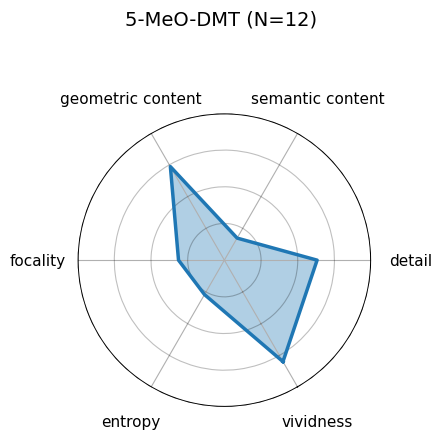

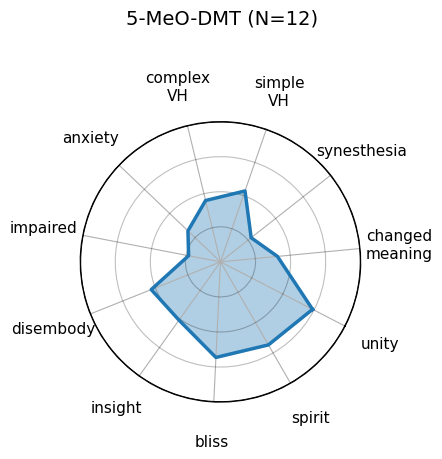

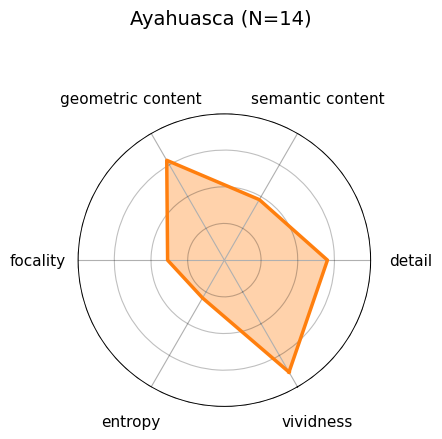

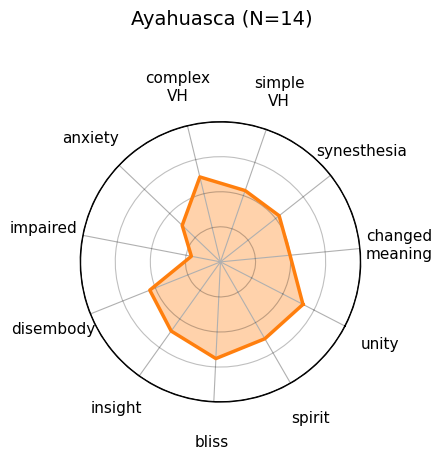

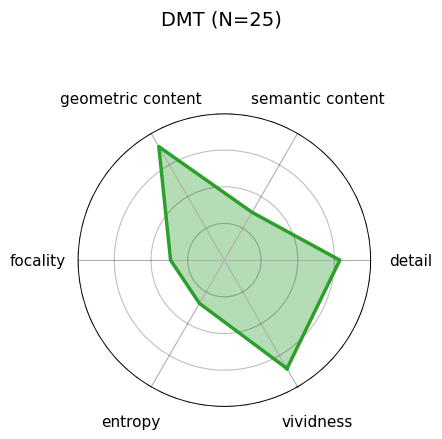

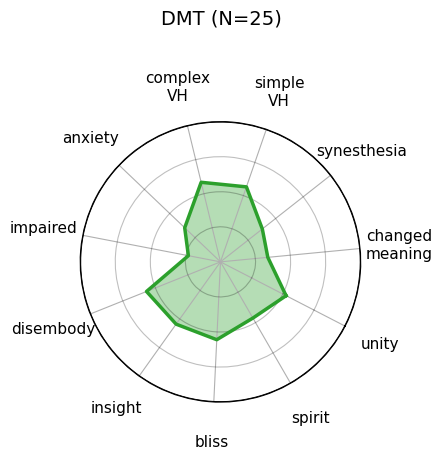

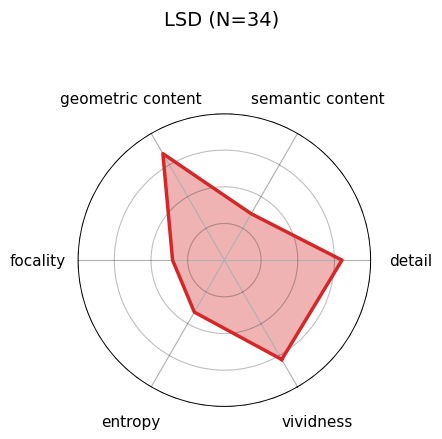

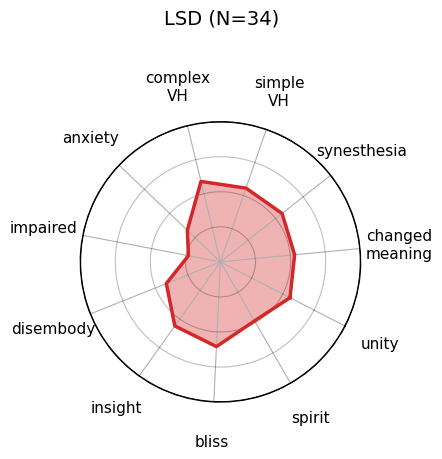

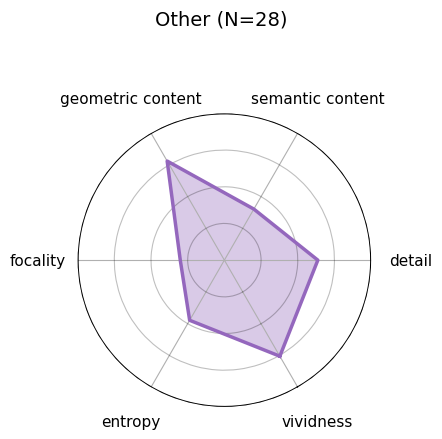

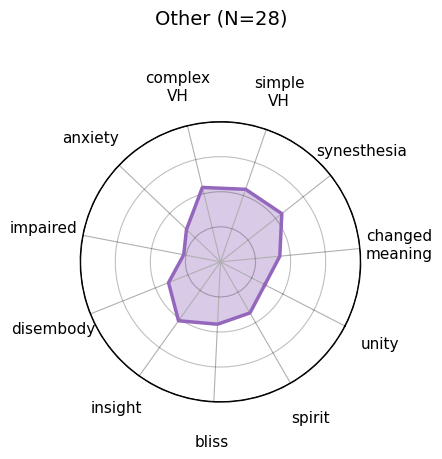

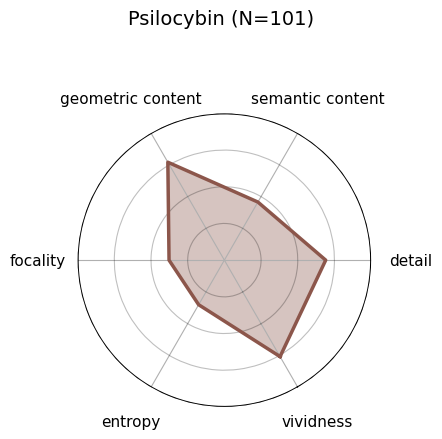

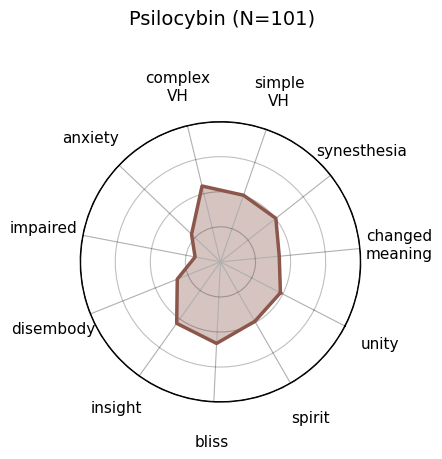

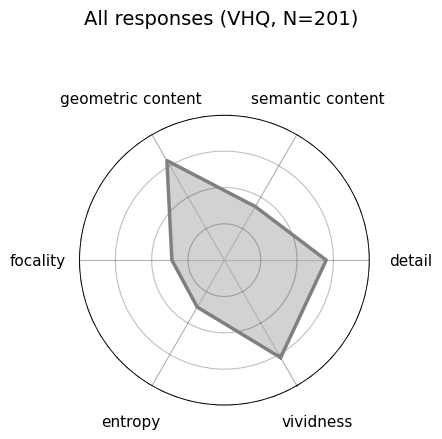

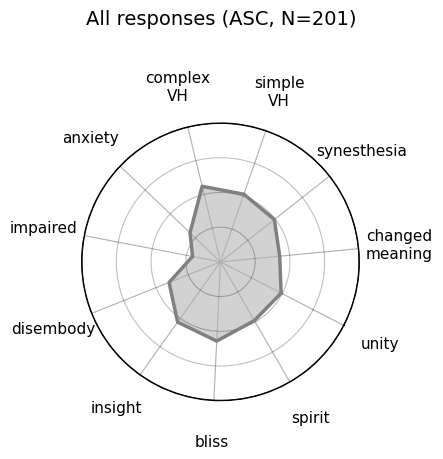

In [ ]:


# ============================================
# 0. Helpers
# ============================================

def rotate_labels_and_profile(labels, profile, shift):
    """
    Rotate labels and corresponding profile by `shift` positions.

    Positive shift: move items forward.
    Negative shift: move items backward.
    """
    n = len(labels)
    idx = list(range(n))
    if shift >= 0:
        rot_idx = idx[shift:] + idx[:shift]
    else:
        k = -shift
        rot_idx = idx[-k:] + idx[:-k]

    labels_rot = [labels[i] for i in rot_idx]
    profile_rot = profile[rot_idx]
    return labels_rot, profile_rot


def radar_plot_single(ax, profile, dim_labels, color,
                      y_min, y_max, labelpad, rotation_deg,
                      n_rings=4, ring_color="black", ring_alpha=0.25):
    """
    ax         : polar axes
    profile    : 1D array of values (len = n_dims)
    dim_labels : list of dimension labels (same order as profile)
    color      : line + fill color
    y_min,y_max: radial limits
    labelpad   : padding for angular labels
    rotation_deg : rotation in degrees for this plot
    n_rings    : number of concentric grid circles
    """

    n_dims = len(dim_labels)
    angles = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
    angles += angles[:1]

    theta_off = np.pi/2 + np.deg2rad(rotation_deg)
    ax.set_theta_offset(theta_off)
    ax.set_theta_direction(-1)

    # Theta labels
    ax.set_thetagrids(
        np.degrees(angles[:-1]),
        labels=dim_labels,
        fontsize=11
    )
    ax.tick_params(axis='x', pad=labelpad)

    # Radial limits
    ax.set_ylim(y_min, y_max)

    # Remove y tick labels
    ax.set_yticklabels([])

    # Concentric rings (radial gridlines) + outer border
    ring_vals = np.linspace(y_min, y_max, n_rings + 1)[1:]  # skip center
    ax.set_yticks(ring_vals)
    ax.grid(which="both", axis="y", color=ring_color, alpha=ring_alpha)

    # Outer border: draw final ring darker & thicker
    theta_border = np.linspace(0, 2 * np.pi, 400)
    r_border = np.full_like(theta_border, y_max)
    ax.plot(theta_border, r_border, color="black", linewidth=1.4)

    # Main polygon
    vals = profile.tolist() + profile.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=2.5)
    ax.fill(angles, vals, color=color, alpha=0.35)


# ============================================
# 1. Labels and index-space rotations
# ============================================

vhq_labels_orig = list(vhq_dimensions)   # 6D VHQ labels
asc_labels_orig = list(asc_dimensions)   # 11D ASC labels (canonical order)

# Index-space rotation:
#   - VHQ: we rotate in index-space
#   - ASC: we DO NOT rotate in index-space (keep canonical order)
vhq_shift = len(vhq_labels_orig) // 2    # for 6 dims: shift by 3
# ASC: no index shift


# ============================================
# 2. Angular rotations (visual orientation)
# ============================================

# Original VHQ rotation
rotation_deg_vhq = -330 + 180  # -150 degrees

# ASC rotation: shift visually so that dim 1 sits in a "nice" position,
# but WITHOUT changing the dimension order
rotation_deg_asc = rotation_deg_vhq + 360 * 1 / 11


# ============================================
# 3. Substances and bright colours (no greys)
# ============================================

substances_sorted = sorted(valid_substances)

# Use tab10 but skip the grey-ish colour at index 7
base_cmap = plt.cm.get_cmap("tab10")
colors = []
j = 0
while len(colors) < len(substances_sorted):
    idx = j
    if idx == 7:          # skip the grey-ish colour
        j += 1
        idx = j
    colors.append(base_cmap(idx))
    j += 1

substance_colors = {sub: colors[i] for i, sub in enumerate(substances_sorted)}


# ============================================
# 4. Numeric labels + mapping for ASC (canonical order)
# ============================================

asc_dim_numbers = [str(i + 1) for i in range(len(asc_labels_orig))]

asc_short_dim_names = [
    "unity",
    "spirit",
    "bliss",
    "insight",
    "disembody",
    "impaired",
    "anxiety",
    "complex\nVH",
    "simple\nVH",
    "synesthesia",
    "changed\nmeaning"
]

print("ASC dimension mapping (number -> label, canonical order):")
for i, lbl in enumerate(asc_labels_orig, start=1):
    print(f"{i}: {lbl}")


# ============================================
# 5. Separate radar plots per substance (no mean overlay)
#    (uses df_merge, filtered via valid_substances)
# ============================================

for sub in substances_sorted:
    sub_df = df_merge[df_merge["substance"] == sub]
    n_sub = sub_df["ResponseId"].nunique()

    # Mean profiles for this substance
    vhq_mean = sub_df[vhq_dimension_columns].mean().values
    asc_mean = sub_df[asc_dimension_columns].mean().values

    # VHQ: rotate labels + profile in index-space
    vhq_labels_sub, vhq_mean_rot = rotate_labels_and_profile(
        vhq_labels_orig,
        vhq_mean,
        vhq_shift
    )

    asc_mean_rot = asc_mean

    color = substance_colors[sub]

    # --- VHQ radar (1–5) ---
    fig_vhq, ax_vhq = plt.subplots(
        subplot_kw={"polar": True},
        figsize=(4.5, 4.5)
    )

    radar_plot_single(
        ax=ax_vhq,
        profile=vhq_mean_rot,
        dim_labels=vhq_labels_sub,   # full text labels
        color=color,
        y_min=1.0,
        y_max=5.0,
        labelpad=18,
        rotation_deg=rotation_deg_vhq,
        n_rings=4                  # number of concentric circles for VHQ
    )

    fig_vhq.suptitle(f"{sub} (N={n_sub})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # --- ASC radar (0–100), numeric tick labels hugging the plot ---
    fig_asc, ax_asc = plt.subplots(
        subplot_kw={"polar": True},
        figsize=(4.5, 4.5)
    )

    radar_plot_single(
        ax=ax_asc,
        profile=asc_mean_rot,
        dim_labels=asc_short_dim_names,  
        color=color,
        y_min=0.0,
        y_max=100.0,
        labelpad=18,                  # close to the plot
        rotation_deg=rotation_deg_asc,
        n_rings=4                  # number of concentric circles for ASC
    )

    fig_asc.suptitle(f"{sub} (N={n_sub})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ============================================
# 6. Overall radar plots for full VHQ / ASC datasets
# ============================================

# --- VHQ: mean over full df_vhq_rec_dims ---
vhq_mean_all_full = df_vhq_rec_dims[vhq_dimension_columns].mean().values

vhq_labels_all_full, vhq_mean_all_full_rot = rotate_labels_and_profile(
    vhq_labels_orig,
    vhq_mean_all_full,
    vhq_shift
)

# N across all VHQ responses
if "ResponseId" in df_vhq_rec_dims.columns:
    N_vhq_all = df_vhq_rec_dims["ResponseId"].nunique()
else:
    N_vhq_all = len(df_vhq_rec_dims)

fig_vhq_all, ax_vhq_all = plt.subplots(
    subplot_kw={"polar": True},
    figsize=(4.5, 4.5)
)

radar_plot_single(
    ax=ax_vhq_all,
    profile=vhq_mean_all_full_rot,
    dim_labels=vhq_labels_all_full,
    color="grey",
    y_min=1.0,
    y_max=5.0,
    labelpad=19,
    rotation_deg=rotation_deg_vhq,
    n_rings=4
)

fig_vhq_all.suptitle(f"All responses (VHQ, N={N_vhq_all})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- ASC: mean over full df_asc_rec_dims ---
asc_mean_all_full = df_asc_rec_dims[asc_dimension_columns].mean().values

asc_mean_all_full_rot = asc_mean_all_full

# N across all ASC responses
if "ResponseId" in df_asc_rec_dims.columns:
    N_asc_all = df_asc_rec_dims["ResponseId"].nunique()
else:
    N_asc_all = len(df_asc_rec_dims)

fig_asc_all, ax_asc_all = plt.subplots(
    subplot_kw={"polar": True},
    figsize=(4.5, 4.5)
)

radar_plot_single(
    ax=ax_asc_all,
    profile=asc_mean_all_full_rot,
    dim_labels=asc_short_dim_names, 
    color="grey",
    y_min=0.0,
    y_max=100.0,
    labelpad=19,
    rotation_deg=rotation_deg_asc,
    n_rings=4
)

fig_asc_all.suptitle(f"All responses (ASC, N={N_asc_all})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Spider Plots for Main Text Figure 4

In [24]:
# ============================================
# 7. Minimal, bold radar plots for slide export
# ============================================
import numpy as np
import matplotlib.pyplot as plt

# Visual style (tweak if you like)
fig_width    = 4.5
fig_height   = 4.5
lw_line      = 2.0
alpha_fill   = 0.25
grid_lw      = 2.2

def _compute_angles(n_dims):
    """Angles closed (first = last)."""
    ang = np.linspace(0, 2 * np.pi, n_dims, endpoint=False).tolist()
    ang += ang[:1]
    return ang

def make_minimal_radar(profile, y_min, y_max, rotation_deg,
                       color="black", radial_ticks=None):
    """
    Minimal “bold” radar: thick grid, no labels, no legend or title.
    """
    profile = np.asarray(profile)
    n_dims  = profile.size
    angles  = _compute_angles(n_dims)

    if radial_ticks is None:
        radial_ticks = np.linspace(y_min, y_max, 5)

    fig = plt.figure(figsize=(fig_width, fig_height))
    ax  = fig.add_subplot(111, polar=True)

    # Orientation (keep exactly the same as earlier code)
    ax.set_theta_offset(np.pi/2 + np.deg2rad(rotation_deg))
    ax.set_theta_direction(-1)

    # No dimension labels
    ax.set_thetagrids(np.degrees(angles[:-1]), labels=[])

    # Radial axis: grid only
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([])

    # Thick gridlines
    ax.grid(True)
    for gl in ax.xaxis.get_gridlines():
        gl.set_linewidth(grid_lw)
    for gl in ax.yaxis.get_gridlines():
        gl.set_linewidth(grid_lw)

    # Profile polygon
    vals = profile.tolist() + profile.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=lw_line * 1.8)
    ax.fill(angles, vals, color=color, alpha=alpha_fill)

    # No title, no legend
    ax.set_title("")

    plt.tight_layout()
    plt.show()

    return fig, ax

def make_blank_radar_with_labels(dim_labels, y_min, y_max,
                                 rotation_deg, radial_ticks=None):
    """
    Reference radar: only grid + axis labels in the correct places.
    No data polygon, no title, no legend.
    """
    n_dims = len(dim_labels)
    angles = _compute_angles(n_dims)

    if radial_ticks is None:
        radial_ticks = np.linspace(y_min, y_max, 5)

    fig = plt.figure(figsize=(fig_width, fig_height))
    ax  = fig.add_subplot(111, polar=True)

    ax.set_theta_offset(np.pi/2 + np.deg2rad(rotation_deg))
    ax.set_theta_direction(-1)

    # Show labels where axes should be
    ax.set_thetagrids(
        np.degrees(angles[:-1]),
        labels=dim_labels
    )

    ax.set_ylim(y_min, y_max)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([])

    ax.grid(True)
    for gl in ax.xaxis.get_gridlines():
        gl.set_linewidth(grid_lw)
    for gl in ax.yaxis.get_gridlines():
        gl.set_linewidth(grid_lw)

    ax.set_title("")

    plt.tight_layout()
    plt.show()

    return fig, ax



Main-text VHQ radar – all substances averaged (N=201)


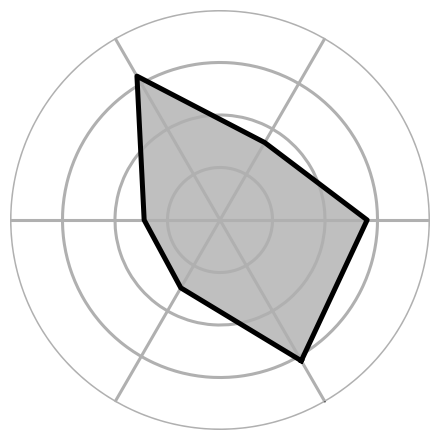

Main-text ASC radar – all substances averaged (N=201)


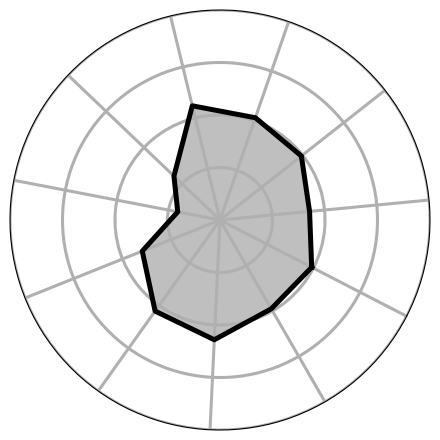

Main-text VHQ radar – 5-MeO-DMT (N=12) vs rest (N=189)


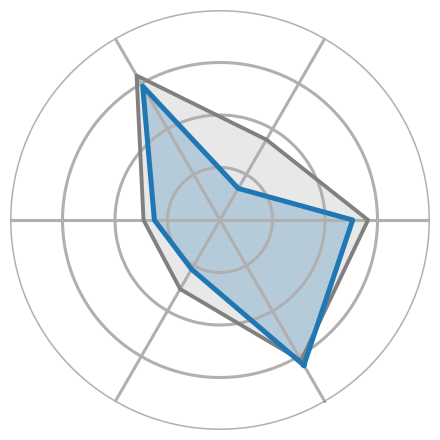

Main-text ASC radar – 5-MeO-DMT (N=12) vs rest (N=189)


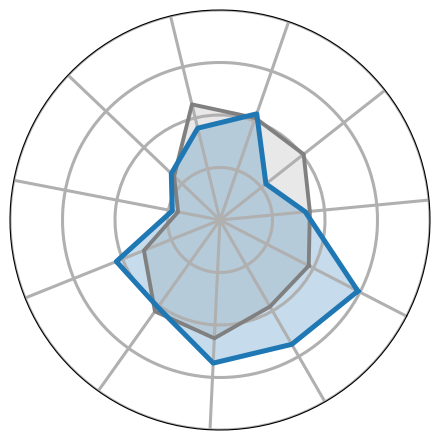

Main-text VHQ radar – Psilocybin (N=101) vs rest (N=100)


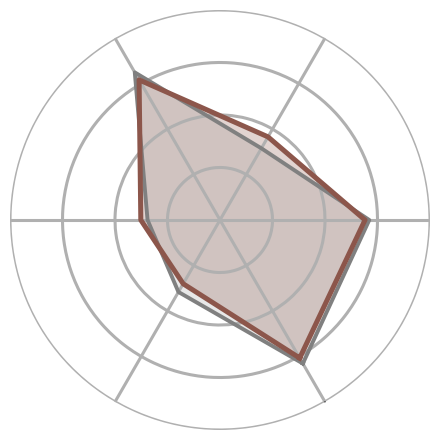

Main-text ASC radar – Psilocybin (N=101) vs rest (N=100)


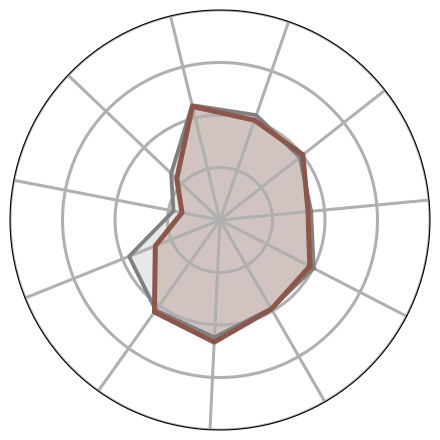

(<Figure size 450x450 with 1 Axes>, <PolarAxes: >)

In [ ]:
# ============================================
# 8. Main-text radar plots (minimal, bold)
#   - All-substances average (black): VHQ + ASC
#   - 5-MeO-DMT vs rest: VHQ + ASC (rest in grey behind, 5-MeO in color)
#   - Psilocybin vs rest: VHQ + ASC (rest in grey behind, psilocybin in color)
# ============================================


def mean_profile_for_substance(substance_name, dim_cols):
    sub_df = df_merge[df_merge["substance"] == substance_name]
    n_sub = sub_df["ResponseId"].nunique()
    prof = sub_df[list(dim_cols)].mean().values
    return prof, n_sub, sub_df

def mean_profile_for_ids(response_ids, dim_cols):
    df = df_resp[df_resp["ResponseId"].isin(response_ids)]
    n = df["ResponseId"].nunique()
    prof = df[list(dim_cols)].mean().values
    return prof, n

def make_minimal_radar_overlay(
    profile_back, profile_front,
    y_min, y_max, rotation_deg,
    color_back="grey", color_front="black",
    radial_ticks=None,
    alpha_back=0.18, alpha_front=alpha_fill,
    lw_back=None, lw_front=None
):
    """
    Minimal radar with two polygons:
      - background (e.g., rest-of-data) drawn first
      - foreground (e.g., substance-of-interest) drawn on top
    Uses the SAME style parameters as section 7 (grid, no labels), without redefining them.
    """
    if lw_back is None:
        lw_back = lw_line * 1.4
    if lw_front is None:
        lw_front = lw_line * 1.8

    profile_back = np.asarray(profile_back)
    profile_front = np.asarray(profile_front)

    n_dims = profile_front.size
    angles = _compute_angles(n_dims)

    if radial_ticks is None:
        radial_ticks = np.linspace(y_min, y_max, 5)

    fig = plt.figure(figsize=(fig_width, fig_height))
    ax = fig.add_subplot(111, polar=True)

    ax.set_theta_offset(np.pi/2 + np.deg2rad(rotation_deg))
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels=[])

    ax.set_ylim(y_min, y_max)
    ax.set_yticks(radial_ticks)
    ax.set_yticklabels([])

    ax.grid(True)
    for gl in ax.xaxis.get_gridlines():
        gl.set_linewidth(grid_lw)
    for gl in ax.yaxis.get_gridlines():
        gl.set_linewidth(grid_lw)

    # Background polygon
    vals_b = profile_back.tolist() + profile_back.tolist()[:1]
    ax.plot(angles, vals_b, color=color_back, linewidth=lw_back)
    ax.fill(angles, vals_b, color=color_back, alpha=alpha_back)

    # Foreground polygon
    vals_f = profile_front.tolist() + profile_front.tolist()[:1]
    ax.plot(angles, vals_f, color=color_front, linewidth=lw_front)
    ax.fill(angles, vals_f, color=color_front, alpha=alpha_front)

    ax.set_title("")
    plt.tight_layout()
    plt.show()
    return fig, ax


# --------------------------------------------
# 8a. All-substances average (black)
# --------------------------------------------
# For this dataset, "all-substances average" is simply the mean over all respondents
# (because each respondent contributes once). We use the already computed full-dataset means.

print(f"Main-text VHQ radar – all substances averaged (N={N_vhq_all})")
make_minimal_radar(
    profile      = vhq_mean_all_full_rot,
    y_min        = 1.0,
    y_max        = 5.0,
    rotation_deg = rotation_deg_vhq,
    color        = "black",
    radial_ticks = [1, 2, 3, 4, 5]
)

print(f"Main-text ASC radar – all substances averaged (N={N_asc_all})")
make_minimal_radar(
    profile      = asc_mean_all_full_rot,
    y_min        = 0.0,
    y_max        = 100.0,
    rotation_deg = rotation_deg_asc,
    color        = "black",
    radial_ticks = [0, 25, 50, 75, 100]
)


# --------------------------------------------
# 8b. 5-MeO-DMT vs rest (grey behind)
# --------------------------------------------
# Use respondent-level grouping to avoid duplication in "rest":
#   - group = respondents who reported 5-MeO-DMT
#   - rest  = respondents who did not report 5-MeO-DMT

target = "5-MeO-DMT"
ids_in_group = [rid for rid, cats in resp_cats.items() if target in cats]
ids_rest     = [rid for rid, cats in resp_cats.items() if target not in cats]

# VHQ profiles
vhq_group, n_group_vhq = mean_profile_for_ids(ids_in_group, vhq_dimension_columns)
vhq_rest,  n_rest_vhq  = mean_profile_for_ids(ids_rest,     vhq_dimension_columns)

_, vhq_group_rot = rotate_labels_and_profile(vhq_labels_orig, vhq_group, vhq_shift)
_, vhq_rest_rot  = rotate_labels_and_profile(vhq_labels_orig, vhq_rest,  vhq_shift)

print(f"Main-text VHQ radar – {target} (N={n_group_vhq}) vs rest (N={n_rest_vhq})")
make_minimal_radar_overlay(
    profile_back  = vhq_rest_rot,
    profile_front = vhq_group_rot,
    y_min         = 1.0,
    y_max         = 5.0,
    rotation_deg  = rotation_deg_vhq,
    color_back    = "grey",
    color_front   = substance_colors[target],
    radial_ticks  = [1, 2, 3, 4, 5],
    alpha_back    = 0.18,
    alpha_front   = alpha_fill
)

# ASC profiles
asc_group, n_group_asc = mean_profile_for_ids(ids_in_group, asc_dimension_columns)
asc_rest,  n_rest_asc  = mean_profile_for_ids(ids_rest,     asc_dimension_columns)

asc_group_rot = asc_group
asc_rest_rot  = asc_rest

print(f"Main-text ASC radar – {target} (N={n_group_asc}) vs rest (N={n_rest_asc})")
make_minimal_radar_overlay(
    profile_back  = asc_rest_rot,
    profile_front = asc_group_rot,
    y_min         = 0.0,
    y_max         = 100.0,
    rotation_deg  = rotation_deg_asc,
    color_back    = "grey",
    color_front   = substance_colors[target],
    radial_ticks  = [0, 25, 50, 75, 100],
    alpha_back    = 0.18,
    alpha_front   = alpha_fill
)


# --------------------------------------------
# 8c. Psilocybin vs rest (grey behind)
# --------------------------------------------
target = "Psilocybin"
ids_in_group = [rid for rid, cats in resp_cats.items() if target in cats]
ids_rest     = [rid for rid, cats in resp_cats.items() if target not in cats]

# VHQ profiles
vhq_group, n_group_vhq = mean_profile_for_ids(ids_in_group, vhq_dimension_columns)
vhq_rest,  n_rest_vhq  = mean_profile_for_ids(ids_rest,     vhq_dimension_columns)

_, vhq_group_rot = rotate_labels_and_profile(vhq_labels_orig, vhq_group, vhq_shift)
_, vhq_rest_rot  = rotate_labels_and_profile(vhq_labels_orig, vhq_rest,  vhq_shift)

print(f"Main-text VHQ radar – {target} (N={n_group_vhq}) vs rest (N={n_rest_vhq})")
make_minimal_radar_overlay(
    profile_back  = vhq_rest_rot,
    profile_front = vhq_group_rot,
    y_min         = 1.0,
    y_max         = 5.0,
    rotation_deg  = rotation_deg_vhq,
    color_back    = "grey",
    color_front   = substance_colors[target],
    radial_ticks  = [1, 2, 3, 4, 5],
    alpha_back    = 0.18,
    alpha_front   = alpha_fill
)

# ASC profiles
asc_group, n_group_asc = mean_profile_for_ids(ids_in_group, asc_dimension_columns)
asc_rest,  n_rest_asc  = mean_profile_for_ids(ids_rest,     asc_dimension_columns)

asc_group_rot = asc_group
asc_rest_rot  = asc_rest

print(f"Main-text ASC radar – {target} (N={n_group_asc}) vs rest (N={n_rest_asc})")
make_minimal_radar_overlay(
    profile_back  = asc_rest_rot,
    profile_front = asc_group_rot,
    y_min         = 0.0,
    y_max         = 100.0,
    rotation_deg  = rotation_deg_asc,
    color_back    = "grey",
    color_front   = substance_colors[target],
    radial_ticks  = [0, 25, 50, 75, 100],
    alpha_back    = 0.18,
    alpha_front   = alpha_fill
)
